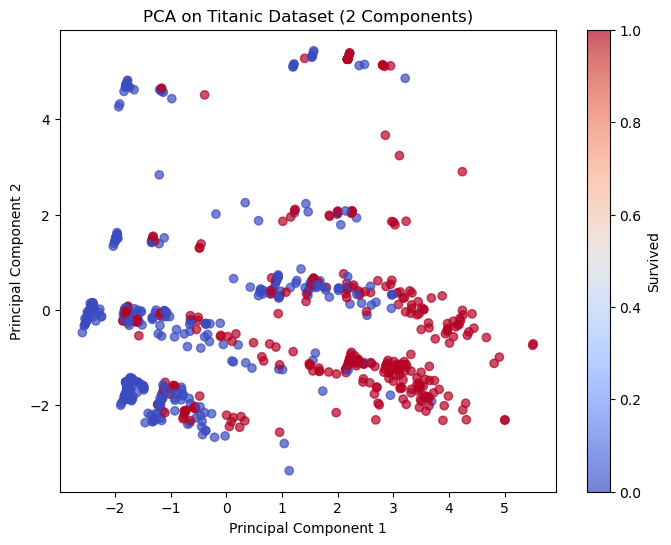

Explained variance ratio: [0.20987854 0.14388177]


In [4]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset
data = sns.load_dataset("titanic")

# Drop irrelevant or high-missing columns safely
data.drop(columns=['name', 'ticket', 'cabin'], errors='ignore', inplace=True)

# Handle missing values
data["age"] = data["age"].fillna(data["age"].median())
data["embarked"] = data["embarked"].fillna(data["embarked"].mode()[0])
data["fare"] = data["fare"].fillna(data["fare"].median())

# Encode categorical variables
data = pd.get_dummies(data, drop_first=True)

# Separate features and target
X = data.drop("survived", axis=1)
y = data["survived"]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Visualize PCA results
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title("PCA on Titanic Dataset (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Survived')
plt.show()

# Explained variance
print("Explained variance ratio:", pca.explained_variance_ratio_)
